In [2]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from pymorphy2 import MorphAnalyzer

import kagglehub
import numpy as np
import os
import json
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans


/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("kkhubiev/russian-financial-news")

parquet_path = os.path.join(path, 'RussianFinancialNews/news_collection.parquet')
df = pd.read_parquet(parquet_path)


In [3]:
df_moex = pd.read_csv('all_moex_data_combined.csv')

In [11]:
df_moex[df_moex['TRADEDATE'] == '2022-01-03']

,TRADEDATE,BOARDID,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,...,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE,Ticker
0,2022-01-03,TQBR,Система ао,AFKS,16818,7.599809e+08,23.45,23.311,24.55,24.30,...,24.30,6.278949e+08,6.278949e+08,6.278949e+08,0,3,SUR,4.93,NaN,AFKS
1,2022-01-03,TQBR,Аэрофлот,AFLT,21502,5.547916e+08,59.16,59.100,60.90,60.78,...,60.78,4.416604e+08,4.416604e+08,4.416604e+08,0,3,SUR,2.60,NaN,AFLT
2,2022-01-03,TQBR,АЛРОСА ао,ALRS,25172,1.151540e+09,122.46,122.220,123.91,122.80,...,122.80,9.356188e+08,9.356188e+08,9.356188e+08,0,3,SUR,0.76,NaN,ALRS
3,2022-01-03,TQBR,Башнефт ап,BANEP,2690,7.003149e+07,1010.00,1000.500,1028.00,1026.00,...,1026.00,7.003149e+07,7.003149e+07,7.003149e+07,0,3,SUR,3.06,NaN,BANEP
4,2022-01-03,TQBR,БСП ао,BSPB,2196,2.149682e+07,81.80,81.020,85.00,84.18,...,84.18,2.149682e+07,2.149682e+07,2.149682e+07,0,3,SUR,3.29,NaN,BSPB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,2022-01-03,TQBR,ЦМТ ао,WTCM,161,4.644020e+05,9.68,9.680,10.90,9.70,...,9.70,0.000000e+00,5.002440e+05,0.000000e+00,0,3,SUR,0.62,NaN,WTCM
112,2022-01-03,TQBR,ЦМТ ап,WTCMP,229,5.647940e+05,8.50,8.420,9.16,8.54,...,8.54,5.647940e+05,5.647940e+05,5.647940e+05,0,3,SUR,1.18,NaN,WTCMP
113,2022-01-03,TQBR,ЯТЭК ао,YAKG,132,1.658403e+06,112.30,112.000,115.95,113.05,...,113.05,1.658403e+06,1.658403e+06,1.658403e+06,0,3,SUR,0.98,NaN,YAKG
114,2022-01-03,TQBR,Yandex clA,YNDX,45440,3.878035e+09,4569.40,4503.200,4631.80,4559.40,...,4559.40,2.618629e+09,2.618629e+09,2.618629e+09,0,3,SUR,-1.19,NaN,YNDX


In [12]:
df_moex[df_moex['TRADEDATE'] == '2022-01-04']

,TRADEDATE,BOARDID,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,...,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE,Ticker
116,2022-01-04,TQBR,Система ао,AFKS,20699,1.022883e+09,24.53,24.467,25.295,24.637,...,24.637,7.265750e+08,7.265750e+08,7.265750e+08,0,3,SUR,0.78,NaN,AFKS
117,2022-01-04,TQBR,Аэрофлот,AFLT,32235,1.129608e+09,60.92,60.380,63.360,63.060,...,63.060,9.348707e+08,9.348707e+08,9.348707e+08,0,3,SUR,4.28,NaN,AFLT
118,2022-01-04,TQBR,АЛРОСА ао,ALRS,25919,1.400442e+09,123.39,122.410,124.320,124.100,...,124.100,1.234868e+09,1.234868e+09,1.234868e+09,0,3,SUR,0.45,NaN,ALRS
119,2022-01-04,TQBR,Башнефт ап,BANEP,2478,6.368952e+07,1029.00,1020.000,1047.000,1047.000,...,1047.000,6.368952e+07,6.368952e+07,6.368952e+07,0,3,SUR,2.05,NaN,BANEP
120,2022-01-04,TQBR,БСП ао,BSPB,3953,5.272291e+07,84.20,84.200,90.000,87.100,...,87.100,5.272291e+07,5.272291e+07,5.272291e+07,0,3,SUR,3.47,NaN,BSPB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227,2022-01-04,TQBR,ЦМТ ао,WTCM,39,2.257180e+05,9.70,9.700,9.940,9.940,...,9.940,0.000000e+00,5.026700e+05,0.000000e+00,0,3,SUR,2.47,NaN,WTCM
228,2022-01-04,TQBR,ЦМТ ап,WTCMP,25,1.114060e+05,8.54,8.540,8.760,8.760,...,8.760,0.000000e+00,5.015560e+05,0.000000e+00,0,3,SUR,2.58,NaN,WTCMP
229,2022-01-04,TQBR,ЯТЭК ао,YAKG,162,1.660145e+06,113.00,110.900,115.700,114.350,...,114.350,1.660145e+06,1.660145e+06,1.660145e+06,0,3,SUR,1.64,NaN,YAKG
230,2022-01-04,TQBR,Yandex clA,YNDX,46227,4.082157e+09,4525.80,4413.000,4577.000,4454.200,...,4454.200,2.750187e+09,2.750187e+09,2.750187e+09,0,3,SUR,-0.78,NaN,YNDX


In [5]:
df

,title,body,date,time,tags,source
0,no title,"""После падения добычи в 2022-2023 годах Газпро...",2024-09-09,16:16:54,['цифры'],rdv
1,no title,""" Рейтинг акций комьюнити РДВ. #опрос """,2024-09-09,15:38:21,['опрос'],rdv
2,no title,"""Нефть Brent упала до $71, Urals - до $60 за б...",2024-09-09,14:40:17,['шокновости'],rdv
3,no title,"""️ Ставка ЦБ вряд ли уйдёт выше 18%. ЦБ переже...",2024-09-09,12:54:10,['VIPtalk'],rdv
4,no title,"""Эксперты клуба RDV PREMIUM 361° дали коммента...",2024-09-09,10:25:07,[],rdv
...,...,...,...,...,...,...
92372,no title,Покупка многофункционального комплекса Moscow ...,2024-12-15,not stated,no tags,smart_lab
92373,no title,По итогам ноября 2024г объем наличной валюты у...,2024-12-15,not stated,no tags,smart_lab
92374,no title,«Смертность бизнеса» снизилась до минимума с 2...,2024-12-15,not stated,no tags,smart_lab
92375,no title,Александр Новак: Правительство России будет по...,2024-12-15,not stated,no tags,smart_lab


In [6]:
df[df['title'] != 'no title'].shape

(46417, 6)

In [7]:
import requests
from nltk.corpus import stopwords
import nltk

# Пробуем загрузить локально, а если нет — скачать вручную
try:
    stop_words = stopwords.words('russian')
except LookupError:
    print("Stopwords not found, downloading manually...")
    url = "https://raw.githubusercontent.com/stopwords-iso/stopwords-ru/master/stopwords-ru.txt"
    text = requests.get(url).text
    stop_words = text.splitlines()

print(f"Loaded {len(stop_words)} Russian stopwords")


Stopwords not found, downloading manually...
Loaded 559 Russian stopwords


In [8]:
# Combine 'title' and 'body' into one column
df['text'] = (df['title'].fillna('') + ' ' + df['body'].fillna('')).str.strip()

In [9]:

def clean_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'#[\w-]+|@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'[^а-яА-Яa-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.replace('no title', '').replace('title', '')

    return text.strip()

df['clean_text'] = df['text'].apply(clean_text)


In [10]:
# Convert all text to lowercase
df['clean_text'] = df['clean_text'].str.lower()


In [11]:
def remove_stopwords(text):
    tokens = [word for word in text.split() if word not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

In [12]:
import inspect
if not hasattr(inspect, "getargspec"):
    from collections import namedtuple
    ArgSpec = namedtuple('ArgSpec', 'args varargs keywords defaults')
    def getargspec(func):
        return ArgSpec(*inspect.getfullargspec(func)[:4])
    inspect.getargspec = getargspec

from pymorphy2 import MorphAnalyzer
morph = MorphAnalyzer()


/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/pymorphy2/analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [13]:
# Initialize the Russian lemmatizer
morph = MorphAnalyzer()

def lemmatize_text(text):
    tokens = text.split()
    lemmas = [morph.parse(word)[0].normal_form for word in tokens]
    return ' '.join(lemmas)

df['clean_text'] = df['clean_text'].apply(lemmatize_text)


In [14]:
# View the cleaned text
df[['text', 'clean_text']].head()

,text,clean_text
0,"no title ""После падения добычи в 2022-2023 год...",падение добыча год газпром добывать газ раз не...
1,"no title "" Рейтинг акций комьюнити РДВ. #опрос...",рейтинг акция комьюнити рдв
2,"no title ""Нефть Brent упала до $71, Urals - до...",нефть brent упасть urals баррель мнение источн...
3,"no title ""️ Ставка ЦБ вряд ли уйдёт выше 18%. ...",ставка цб вряд уйд выше цб пережестить текущий...
4,"no title ""Эксперты клуба RDV PREMIUM 361° дали...",эксперт клуб rdv premium дать комментарий акци...


In [15]:
# Use preprocessed text
texts = df['clean_text'].dropna().tolist()

print(f"Number of documents: {len(texts)}")

Number of documents: 91955


In [16]:
# Create TF-IDF representation of the text corpus
vectorizer = TfidfVectorizer(
    max_features=5000,       # limit number of features for performance
    min_df=5,                # ignore words that appear in fewer than 5 docs
    max_df=0.5,              # ignore very frequent words
    ngram_range=(1, 2)       # use unigrams and bigrams
)

tfidf_matrix = vectorizer.fit_transform(texts)
print("TF-IDF matrix shape:", tfidf_matrix.shape)


TF-IDF matrix shape: (91955, 5000)


- There are 91955 news articles in the dataset.

- Each is represented by 5000 unique TF-IDF features (words or bigrams) that capture the most informative terms across the corpus.

In [17]:
# Define number of clusters (you can adjust later)
NUM_CLUSTERS = 10

kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
kmeans.fit(tfidf_matrix)

# Assign cluster labels to each document
df['cluster'] = kmeans.labels_


In [18]:
# Get the feature (word) names
terms = vectorizer.get_feature_names_out()

def get_top_keywords_per_cluster(tfidf_matrix, labels, terms, n_terms=10):
    cluster_keywords = {}
    for cluster_num in range(NUM_CLUSTERS):
        # Get indices of docs in this cluster
        indices = np.where(labels == cluster_num)
        # Compute average TF-IDF score for each term in this cluster
        mean_tfidf = np.mean(tfidf_matrix[indices], axis=0)
        mean_tfidf = np.squeeze(np.asarray(mean_tfidf))
        # Sort terms by TF-IDF score
        top_indices = mean_tfidf.argsort()[-n_terms:][::-1]
        top_terms = [terms[i] for i in top_indices]
        cluster_keywords[cluster_num] = top_terms
    return cluster_keywords

cluster_keywords = get_top_keywords_per_cluster(tfidf_matrix, kmeans.labels_, terms)


In [19]:
# Print the top keywords for each cluster
for cluster_num, keywords in cluster_keywords.items():
    print(f"Cluster {cluster_num}: {', '.join(keywords)}")


Cluster 0: россия, банк россия, банк, инфляция, вырасти, виктор романовский, романовский, виктор, санкция, инфляция россия
Cluster 1: рынок, российский, российский рынок, индекс, мосбиржа, индекс мосбиржа, торг, акция, рост, рынок акция
Cluster 2: прибыль, чистый, чистый прибыль, мсфо, выручка, млрд, рсб, квартал, млрд рубль, руб
Cluster 3: акция, компания, рф, рынок, российский, банк, рост, инвестор, результат, сша
Cluster 4: рубль, млрд рубль, млрд, доллар, курс, трлн рубль, составить, трлн, валюта, россия
Cluster 5: отчёт рсб, рсб, отчёт, энерго, россеть, группа, гк, соллерс, холдинг, компания
Cluster 6: нефть, газ, газпром, поставка, млн, экспорт, добыча, российский, тонна, цена
Cluster 7: ставка, цб, цб рф, рф, ключевой ставка, банк, ключевой, инфляция, повышение, заседание
Cluster 8: дивиденд, совет, совет директор, директор, сд, акционер, акция, выплата, рекомендовать, рубль
Cluster 9: бкс, ооо компания, компания бкс, ооо, информация, компания, инвестиционный, являться, акция, ц

In [20]:
industry_labels = {
    0: 'Corporate governance',
    1: 'Energy, Oil & Gas',
    2: 'finance',
    3: 'Investment',
    4: 'Financial reports',
    5: 'Banking',
    6: 'Stock market',
    7: 'Corporate finance',
    8: 'Russian banks',
    9: 'Market'
}

df['industry'] = df['cluster'].map(industry_labels)


In [21]:
df['industry'].value_counts().plot(kind='bar', figsize=(8,4), title='News count by industry')

NameError: name 'df' is not defined

#### Conclusions:

- The clusters are logically coherent- they capture financial and industrial sectors: energy, banks, markets, company reports.

- The Investment category overwhelmingly dominates the dataset, suggesting that most news items focus on investment activity, market opportunities, or capital allocation. This may reflect high public and media interest in investment instruments and financial returns during the analyzed period.

- This reflects the central role of the financial sector in Russian economic news- banks are key players in regulation, lending, and corporate finance.

- Other sectors such as Market, Energy (Oil & Gas), and Stock market show moderate coverage, indicating steady reporting on overall economic performance and energy trends.

- Smaller but notable clusters like Corporate governance, Russian banks, and Financial reports represent company-level or institutional updates rather than macroeconomic news.

- Overall, the distribution shows that the dataset is strongly investment-driven, with financial and market-related topics dominating over traditional industrial sectors.

In [22]:
industry_counts = df['industry'].value_counts().reset_index()
industry_counts.columns = ['industry', 'count']
print(industry_counts)


               industry  count
0            Investment  42152
1                Market   8502
2     Energy, Oil & Gas   8182
3          Stock market   7509
4  Corporate governance   6676
5         Russian banks   5256
6     Financial reports   4981
7     Corporate finance   4505
8               finance   3527
9               Banking    665


In [23]:
# Group by date and industry
time_series = (
    df.groupby(['date', 'industry'])
      .size()
      .reset_index(name='count')
)

# Check the first few rows
time_series.head()


,date,industry,count
0,2009-06-19 00:00:00,"Energy, Oil & Gas",1
1,2011-01-21 00:00:00,"Energy, Oil & Gas",1
2,2011-04-05 00:00:00,"Energy, Oil & Gas",1
3,2011-04-06 00:00:00,"Energy, Oil & Gas",1
4,2011-04-07 00:00:00,"Energy, Oil & Gas",1


In [25]:
# Ensure 'date' column is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Remove rows with invalid or missing dates
df = df.dropna(subset=['date'])


In [26]:
print(df['date'].dtype)
# должно вывести: datetime64[ns]


datetime64[ns]


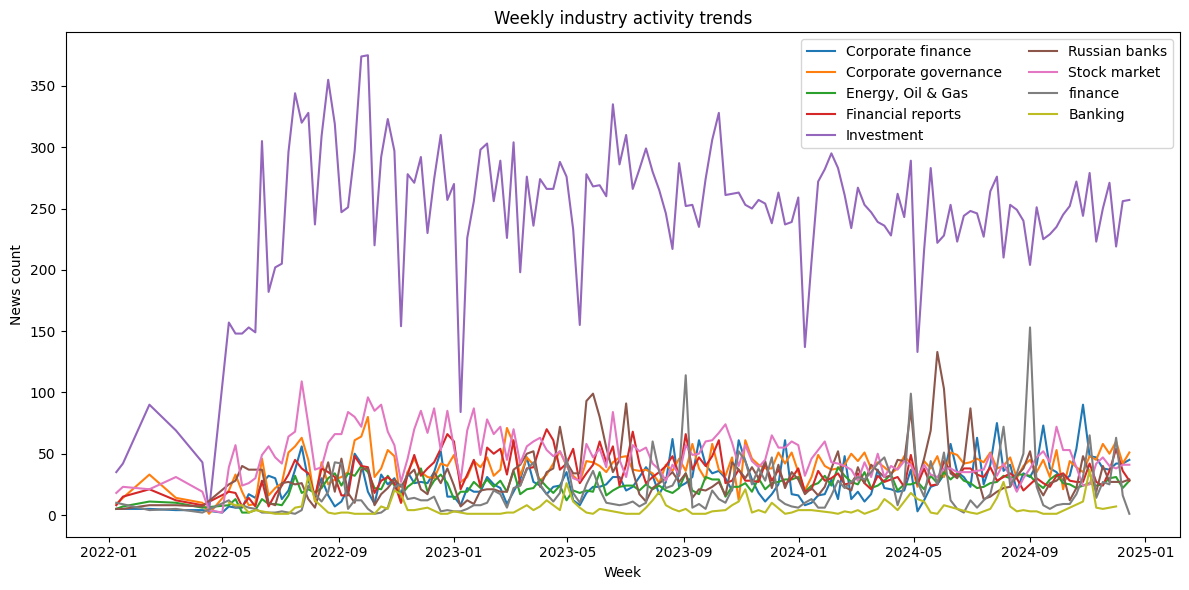

In [27]:
weekly_activity = (
    df.groupby([pd.Grouper(key='date', freq='W'), 'industry'])
      .size()
      .reset_index(name='count')
)

plt.figure(figsize=(12,6))
for industry in weekly_activity['industry'].unique():
    subset = weekly_activity[weekly_activity['industry'] == industry]
    plt.plot(subset['date'], subset['count'], label=industry)

plt.title('Weekly industry activity trends')
plt.xlabel('Week')
plt.ylabel('News count')
plt.legend(loc='upper right', ncol=2)
plt.tight_layout()
plt.show()


The chart shows that the Investment industry consistently dominates weekly news coverage throughout the period. This suggests a sustained focus on investment activities, market sentiment, and capital flows- likely driven by economic volatility and investor interest in financial instruments.

All other sectors- such as Stock market, Corporate governance, Russian banks, and Energy, Oil & Gas: maintain relatively low but stable visibility, reflecting regular reporting cycles rather than sharp trends.

Occasional peaks in other industries likely correspond to major financial events, policy decisions, or quarterly earnings releases.

In summary: the media landscape is strongly investment-centric, with other financial and corporate topics showing secondary but consistent relevance over time.

In [28]:
import itertools
from collections import Counter

industry_keywords = {
    'Investment': ['инвестиция', 'инвестор', 'капитал', 'вложение', 'прибыль'],
    'Energy, Oil & Gas': ['нефть', 'газ', 'энерго', 'brent', 'добыча'],
    'Market': ['рынок', 'торг', 'индекс', 'котировка'],
    'Stock market': ['акция', 'биржа', 'цб', 'мосбиржа'],
    'Corporate governance': ['директор', 'совет', 'акционер', 'дивиденд'],
    'Russian banks': ['банк', 'втб', 'сбер', 'газпромбанк'],
    'Financial reports': ['отчет', 'мсфо', 'выручка', 'прибыль'],
    'Corporate finance': ['заем', 'облигация', 'финансирование', 'долг'],
    'finance': ['финансы', 'ставка', 'рубль', 'курс'],
    'Banking': ['кредит', 'депозит', 'ипотека', 'банковский']
}


In [29]:
def detect_industries(text):
    text_industries = []
    for industry, keywords in industry_keywords.items():
        if any(word in text for word in keywords):
            text_industries.append(industry)
    return list(set(text_industries))  # avoid duplicates

df['industries_in_text'] = df['clean_text'].apply(detect_industries)


/var/folders/0w/xxx48gr55csb_w73mfm7k80m0000gn/T/ipykernel_3470/3294414894.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['industries_in_text'] = df['clean_text'].apply(detect_industries)


In [30]:
pairs = []

for inds in df['industries_in_text']:
    if len(inds) > 1:
        for combo in itertools.combinations(sorted(inds), 2):
            pairs.append(combo)

pair_counts = Counter(pairs)

# Convert to DataFrame
co_occurrence_df = pd.DataFrame([
    {'Industry A': a, 'Industry B': b, 'Co-occurrences': count}
    for (a, b), count in pair_counts.items()
]).sort_values(by='Co-occurrences', ascending=False)

co_occurrence_df.head(10)


,Industry A,Industry B,Co-occurrences
7,Market,Stock market,8097
9,Stock market,finance,6955
29,Investment,Stock market,5784
8,Market,finance,5375
30,Investment,finance,5042
34,Financial reports,Investment,5006
16,Corporate governance,Stock market,4739
28,Investment,Market,4727
3,"Energy, Oil & Gas",finance,4104
18,Russian banks,Stock market,3972


### Heatmap — inter-industry co-occurrence matrix

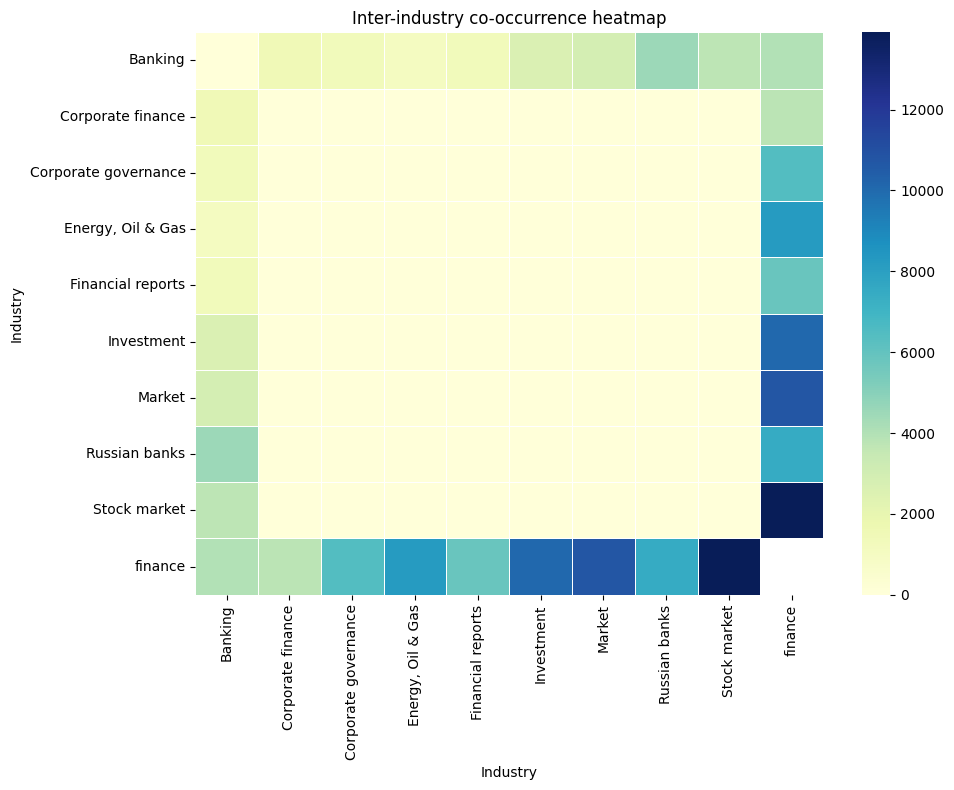

In [32]:
import seaborn as sns
import numpy as np

# Create a pivot table (matrix)
heatmap_data = co_occurrence_df.pivot(
    index='Industry A', columns='Industry B', values='Co-occurrences'
).fillna(0)

# Mirror the matrix for a symmetric heatmap
heatmap_full = heatmap_data.copy()
for a in heatmap_data.columns:
    for b in heatmap_data.index:
        if b not in heatmap_full.columns:
            heatmap_full[b] = 0
        heatmap_full.loc[a, b] = heatmap_full.loc[b, a] if b in heatmap_full.index else 0
heatmap_full = heatmap_full + heatmap_full.T

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_full, cmap='YlGnBu', linewidths=0.5)
plt.title('Inter-industry co-occurrence heatmap')
plt.xlabel('Industry')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()


### Interpretation:

- The “finance” cluster clearly dominates, showing strong co-occurrence with almost every other sector — especially Investment, Stock market, Energy, Oil & Gas, and Financial reports.

- This indicates that financial themes serve as a core linking context across the dataset, integrating news about markets, banks, and corporate performance.

- Other industries show lighter shades (weaker connections), meaning they are more self-contained and rarely appear outside their own context.